## Imports

In [1]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

print('NumPy version :', np.__version__)
print('Imports OK')

NumPy version : 2.0.2
Imports OK


---
## Background

**Generative models for sequences** learn patterns from data and produce new sequences resembling the training distribution.

### What is an LSTM?

An LSTM uses four gates to control information flow:

| Gate | Symbol | Purpose |
|------|--------|---------|
| Input  | $i_t$ | Controls new information entering the cell |
| Forget | $f_t$ | Controls how much past memory to retain |
| Output | $o_t$ | Controls what part of the cell state is output |
| Cell   | $g_t$ | Candidate values to add to the cell state |

---

## Dataset

In [2]:
corpus = """
machine learning models learn patterns from data.
sequence models process data step by step.
recurrent neural networks are designed for sequential tasks.
rnn models maintain hidden states across time steps.
long short term memory networks solve long dependency problems.
lstm uses gates to control information flow.
gru models simplify the lstm architecture.
sequence prediction is useful in many applications.
language modeling predicts the next word in a sentence.
speech recognition processes audio sequences.
time series forecasting predicts future values.
music generation creates new melodies.
generative models learn probability distributions.
they generate new samples similar to training data.
sequence generation is widely used in artificial intelligence.
deep learning improves sequence modeling performance.
""".strip()

print('Corpus loaded:')
print('-' * 60)
print(corpus)
print('-' * 60)

Corpus loaded:
------------------------------------------------------------
machine learning models learn patterns from data.
sequence models process data step by step.
recurrent neural networks are designed for sequential tasks.
rnn models maintain hidden states across time steps.
long short term memory networks solve long dependency problems.
lstm uses gates to control information flow.
gru models simplify the lstm architecture.
sequence prediction is useful in many applications.
language modeling predicts the next word in a sentence.
speech recognition processes audio sequences.
time series forecasting predicts future values.
music generation creates new melodies.
generative models learn probability distributions.
they generate new samples similar to training data.
sequence generation is widely used in artificial intelligence.
deep learning improves sequence modeling performance.
------------------------------------------------------------


---
## Task 1 — Load and Preprocess the Sequential Dataset

In [3]:
# Word-level tokenisation
tokens   = corpus.lower().replace('.', ' .').split()
vocab    = sorted(set(tokens))
V        = len(vocab)
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

print(f'Total tokens   : {len(tokens)}')
print(f'Vocabulary size: {V}')
print(f'Sample vocab   : {vocab[:12]}')
print(f'First 10 tokens: {tokens[:10]}')

Total tokens   : 127
Vocabulary size: 87
Sample vocab   : ['.', 'a', 'across', 'applications', 'architecture', 'are', 'artificial', 'audio', 'by', 'control', 'creates', 'data']
First 10 tokens: ['machine', 'learning', 'models', 'learn', 'patterns', 'from', 'data', '.', 'sequence', 'models']


---
## Task 2 — Convert Sequences into Numerical Representations

In [4]:
token_ids = [word2idx[t] for t in tokens]

print('Word -> Integer Index mapping (first 15 tokens):')
print(f"{'Word':<25} {'Index':>5}")
print('-' * 32)
for tok, idx in zip(tokens[:15], token_ids[:15]):
    print(f'  {tok:<23} {idx:>5}')

Word -> Integer Index mapping (first 15 tokens):
Word                      Index
--------------------------------
  machine                    37
  learning                   34
  models                     43
  learn                      33
  patterns                   49
  from                       19
  data                       11
  .                           0
  sequence                   62
  models                     43
  process                    55
  data                       11
  step                       72
  by                          8
  step                       72


---
## Task 3 — Create Input-Output Sequence Pairs

A sliding window of length `SEQ_LEN` produces training pairs:

```
tokens: [w0, w1, w2, w3, w4, ...]
pair 0: X = [w0, w1, w2]  ->  Y = w3
pair 1: X = [w1, w2, w3]  ->  Y = w4
```

In [5]:
SEQ_LEN = 3    # context window: 3 words -> predict the 4th

X_seqs, Y_seqs = [], []
for i in range(len(tokens) - SEQ_LEN):
    X_seqs.append([word2idx[t] for t in tokens[i : i + SEQ_LEN]])
    Y_seqs.append(word2idx[tokens[i + SEQ_LEN]])

X_seqs = np.array(X_seqs)
Y_seqs = np.array(Y_seqs)
N      = len(X_seqs)

print(f'Number of training pairs : {N}')
print(f'X_seqs shape             : {X_seqs.shape}')
print(f'Y_seqs shape             : {Y_seqs.shape}')
print()
print('First 8 (X -> Y) pairs:')
print(f"  {'Input Context':<45}  Target")
print('  ' + '-' * 58)
for i in range(8):
    x_words = [idx2word[j] for j in X_seqs[i]]
    y_word  = idx2word[Y_seqs[i]]
    print(f'  {str(x_words):<45}  -> {y_word!r}')

Number of training pairs : 124
X_seqs shape             : (124, 3)
Y_seqs shape             : (124,)

First 8 (X -> Y) pairs:
  Input Context                                  Target
  ----------------------------------------------------------
  ['machine', 'learning', 'models']              -> 'learn'
  ['learning', 'models', 'learn']                -> 'patterns'
  ['models', 'learn', 'patterns']                -> 'from'
  ['learn', 'patterns', 'from']                  -> 'data'
  ['patterns', 'from', 'data']                   -> '.'
  ['from', 'data', '.']                          -> 'sequence'
  ['data', '.', 'sequence']                      -> 'models'
  ['.', 'sequence', 'models']                    -> 'process'


---
## Task 4 — Design the LSTM Generative Model

### LSTM Equations

$$i_t = \sigma(W_x x_t + W_h h_{t-1} + b_i)$$
$$f_t = \sigma(W_x x_t + W_h h_{t-1} + b_f)$$
$$o_t = \sigma(W_x x_t + W_h h_{t-1} + b_o)$$
$$g_t = \tanh(W_x x_t + W_h h_{t-1} + b_g)$$
$$c_t = f_t \odot c_{t-1} + i_t \odot g_t$$
$$h_t = o_t \odot \tanh(c_t)$$

### Architecture
```
Input words -> Embedding (D=32) -> LSTM (H=64) -> Linear -> Softmax -> Next word
```

In [6]:
# ── Activation functions ──────────────────────────────────────────
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -15, 15)))

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()


# ── LSTM Model ────────────────────────────────────────────────────
class LSTM:

    def __init__(self, vocab_size, embed_dim, hidden_dim):
        self.V = vocab_size
        self.D = embed_dim
        self.H = hidden_dim

        # Word Embedding: (V, D)
        self.E  = np.random.randn(vocab_size, embed_dim)  * 0.1

        # LSTM weights — all 4 gates stacked
        # Wx: (4H, D),  Wh: (4H, H),  b: (4H,)
        self.Wx = np.random.randn(4 * hidden_dim, embed_dim)  * 0.1
        self.Wh = np.random.randn(4 * hidden_dim, hidden_dim) * 0.1
        self.b  = np.zeros(4 * hidden_dim)

        # Output projection: (V, H)
        self.Wy = np.random.randn(vocab_size, hidden_dim) * 0.1
        self.by = np.zeros(vocab_size)

    def _step(self, x_emb, h, c):
        H = self.H
        gates = self.Wx @ x_emb + self.Wh @ h + self.b   # (4H,)
        i  = sigmoid(gates[     : H])   # input  gate
        f  = sigmoid(gates[H    : 2*H]) # forget gate
        o  = sigmoid(gates[2*H  : 3*H]) # output gate
        g  = np.tanh(gates[3*H  :    ]) # cell   gate
        c_new = f * c + i * g
        h_new = o * np.tanh(c_new)
        cache = (x_emb, h, c, i, f, o, g, c_new, h_new)
        return h_new, c_new, cache

    def forward(self, seq_idx):
        h, c, all_cache = np.zeros(self.H), np.zeros(self.H), []
        for idx in seq_idx:
            h, c, cache = self._step(self.E[idx], h, c)
            all_cache.append((idx, cache))
        probs = softmax(self.Wy @ h + self.by)
        return probs, h, c, all_cache

    def backward(self, seq_idx, target_idx, probs, h_final, all_cache):
        H  = self.H
        gr = {k: np.zeros_like(getattr(self, k))
              for k in ['E', 'Wx', 'Wh', 'b', 'Wy', 'by']}

        # Output layer gradient
        dl             = probs.copy()
        dl[target_idx] -= 1.0
        gr['Wy'] += np.outer(dl, h_final)
        gr['by'] += dl
        dh = self.Wy.T @ dl
        dc = np.zeros(H)

        # BPTT
        for t in reversed(range(len(all_cache))):
            wi, (xe, hp, cp, i, f, o, g, cn, hn) = all_cache[t]
            tc  = np.tanh(cn)
            do  = dh * tc
            dc += dh * o * (1 - tc ** 2)
            di, df, dg = dc * g, dc * cp, dc * i
            dc  = dc * f
            dg_raw = np.concatenate([
                di * i * (1 - i),
                df * f * (1 - f),
                do * o * (1 - o),
                dg * (1 - g ** 2)
            ])
            gr['Wx'] += np.outer(dg_raw, xe)
            gr['Wh'] += np.outer(dg_raw, hp)
            gr['b']  += dg_raw
            gr['E'][wi] += self.Wx.T @ dg_raw
            dh = self.Wh.T @ dg_raw
        return gr

    def adam_update(self, gr, lr, m, v, t,
                    beta1=0.9, beta2=0.999, eps=1e-8):
        for key in ['E', 'Wx', 'Wh', 'b', 'Wy', 'by']:
            g = np.clip(gr[key], -5, 5)
            m[key] = beta1 * m[key] + (1 - beta1) * g
            v[key] = beta2 * v[key] + (1 - beta2) * g ** 2
            mh = m[key] / (1 - beta1 ** t)
            vh = v[key] / (1 - beta2 ** t)
            setattr(self, key,
                    getattr(self, key) - lr * mh / (np.sqrt(vh) + eps))


# Instantiate
D, H  = 32, 64
model = LSTM(vocab_size=V, embed_dim=D, hidden_dim=H)
total = (V*D) + (4*H*D) + (4*H*H) + (4*H) + (V*H) + V
print('LSTM Model')
print('=' * 40)
print(f'  Vocab size   : {V}')
print(f'  Embed dim D  : {D}')
print(f'  Hidden dim H : {H}')
print(f'  Total params : {total:,}')

LSTM Model
  Vocab size   : 87
  Embed dim D  : 32
  Hidden dim H : 64
  Total params : 33,271


---
## Task 5 — Train the Model on the Sequence Dataset

**Loss:** Cross-entropy &nbsp;&nbsp; **Optimizer:** Adam with gradient clipping

$$\mathcal{L} = -\log P(y_{\text{target}} \mid x_1, x_2, x_3)$$

In [7]:
EPOCHS = 200
LR     = 0.005

m_state = {k: np.zeros_like(getattr(model, k))
           for k in ['E', 'Wx', 'Wh', 'b', 'Wy', 'by']}
v_state = {k: np.zeros_like(getattr(model, k))
           for k in ['E', 'Wx', 'Wh', 'b', 'Wy', 'by']}

history_loss = []
history_ppl  = []
t_step       = 0

print(f'Epochs : {EPOCHS}  |  LR : {LR}  |  Pairs : {N}')
print(f"{'Epoch':>7}  {'Loss':>10}  {'Perplexity':>12}")
print('-' * 34)

for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    for idx in np.random.permutation(N):
        t_step += 1
        seq, target = X_seqs[idx].tolist(), int(Y_seqs[idx])
        probs, h_final, _, cache = model.forward(seq)
        total_loss += -np.log(probs[target] + 1e-10)
        grads = model.backward(seq, target, probs, h_final, cache)
        model.adam_update(grads, LR, m_state, v_state, t_step)

    avg = total_loss / N
    ppl = np.exp(avg)
    history_loss.append(avg)
    history_ppl.append(ppl)
    if epoch % 20 == 0 or epoch == 1:
        print(f'{epoch:>7}  {avg:>10.4f}  {ppl:>12.2f}')

print('Training complete')

Epochs : 200  |  LR : 0.005  |  Pairs : 124
  Epoch        Loss    Perplexity
----------------------------------
      1      4.5095         90.88
     20      0.0247          1.03
     40      0.0186          1.02
     60      0.0161          1.02
     80      0.0160          1.02
    100      0.0170          1.02
    120      0.0150          1.02
    140      0.0152          1.02
    160      0.0151          1.02
    180      0.0157          1.02
    200      0.0159          1.02
Training complete


### Training Loss & Perplexity Curves

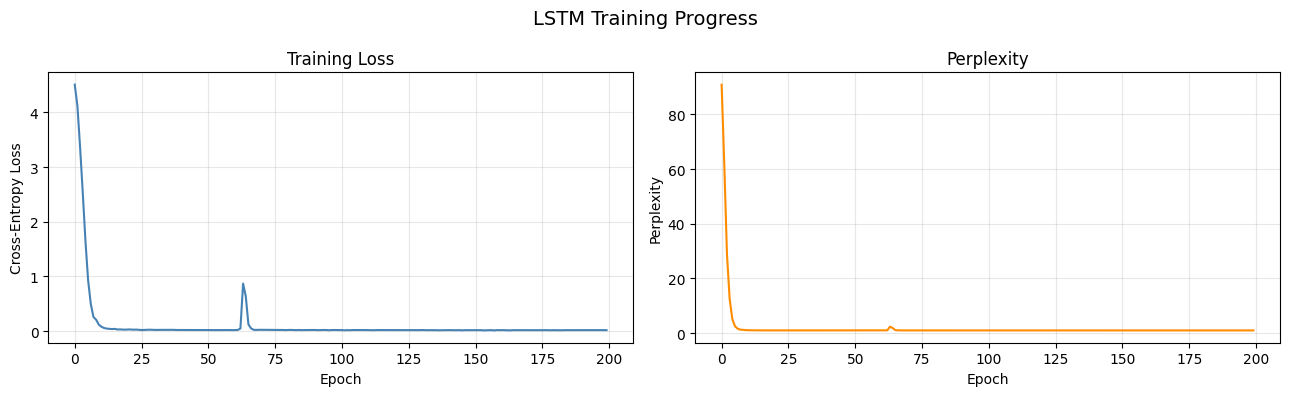

Initial loss : 4.5095  ->  Final loss : 0.0159


In [8]:
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history_loss, color='steelblue', linewidth=1.5)
    axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss'); axes[0].grid(alpha=0.3)
    axes[1].plot(history_ppl, color='darkorange', linewidth=1.5)
    axes[1].set_title('Perplexity'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Perplexity'); axes[1].grid(alpha=0.3)
    plt.suptitle('LSTM Training Progress', fontsize=14)
    plt.tight_layout(); plt.show()
    print(f'Initial loss : {history_loss[0]:.4f}  ->  Final loss : {history_loss[-1]:.4f}')
except ImportError:
    print('Loss (every 20 epochs):', [round(l, 4) for l in history_loss[::20]])

---
## Task 6 — Generate New Sequences Using a Seed Input

**Expected Output:** Generated sequence samples

**Temperature** controls randomness during sampling:
- `temperature < 1` → more conservative
- `temperature > 1` → more creative

In [9]:
def generate_sequence(model, seed_words, length=8, temperature=0.8):
    seq       = [word2idx.get(w, 0) for w in seed_words[-SEQ_LEN:]]
    generated = list(seed_words)
    for _ in range(length):
        probs, _, _, _ = model.forward(seq)
        logits  = np.log(probs + 1e-10) / temperature
        logits -= logits.max()
        scaled  = np.exp(logits)
        scaled /= scaled.sum()
        nxt = np.random.choice(V, p=scaled)
        generated.append(idx2word[nxt])
        seq = seq[1:] + [nxt]
    return ' '.join(generated)


print('=' * 65)
print('EXPECTED OUTPUT - Generated Sequences (LSTM)')
print('=' * 65)

seeds = [
    ['sequence',   'models',   'process'],
    ['deep',       'learning', 'improves'],
    ['lstm',       'uses',     'gates'],
    ['generative', 'models',   'learn'],
    ['language',   'modeling', 'predicts'],
    ['rnn',        'models',   'maintain'],
    ['time',       'series',   'forecasting'],
]

for i, seed in enumerate(seeds, 1):
    out = generate_sequence(model, seed, length=10, temperature=0.8)
    print(f'\n  [{i}] Seed     : {seed}')
    print(f'       Generated: {out}')

print('\n' + '=' * 65)

EXPECTED OUTPUT - Generated Sequences (LSTM)

  [1] Seed     : ['sequence', 'models', 'process']
       Generated: sequence models process data step by step . recurrent neural networks are designed

  [2] Seed     : ['deep', 'learning', 'improves']
       Generated: deep learning improves sequence modeling performance . recurrent uses networks are designed for

  [3] Seed     : ['lstm', 'uses', 'gates']
       Generated: lstm uses gates to control information flow . gru models simplify the lstm

  [4] Seed     : ['generative', 'models', 'learn']
       Generated: generative models learn probability distributions . they generate new samples similar to training

  [5] Seed     : ['language', 'modeling', 'predicts']
       Generated: language modeling predicts the next word in a sentence . speech recognition processes

  [6] Seed     : ['rnn', 'models', 'maintain']
       Generated: rnn models maintain hidden states across time steps . long short term memory

  [7] Seed     : ['time', 'se

### Effect of Temperature on Generated Sequences

In [10]:
seed = ['lstm', 'uses', 'gates']
print(f'Seed: {seed}\n')
print(f"{'Temperature':<14}  Generated Sequence")
print('-' * 70)
for temp in [0.3, 0.6, 0.8, 1.0, 1.3]:
    out = generate_sequence(model, seed, length=8, temperature=temp)
    print(f'  temp={temp:<8}  {out}')

Seed: ['lstm', 'uses', 'gates']

Temperature     Generated Sequence
----------------------------------------------------------------------
  temp=0.3       lstm uses gates to control information flow . gru models simplify
  temp=0.6       lstm uses gates to control information flow . gru models simplify
  temp=0.8       lstm uses gates to control information flow . gru models simplify
  temp=1.0       lstm uses gates to control information flow . gru models simplify
  temp=1.3       lstm uses gates to control information flow . gru models simplify


---
## Evaluation

**Metrics:**
- **Top-1 Accuracy** — model's top prediction matches the target
- **Top-3 Accuracy** — target is within the model's top 3 predictions
- **Perplexity** — $e^{\text{avg loss}}$ (lower is better; 1.0 = perfect)

In [11]:
top1 = top3 = total = 0
for idx in range(N):
    probs, _, _, _ = model.forward(X_seqs[idx].tolist())
    ranked = np.argsort(probs)[::-1]
    target = int(Y_seqs[idx])
    if ranked[0] == target:  top1 += 1
    if target in ranked[:3]: top3 += 1
    total += 1

print('LSTM Evaluation Results')
print('=' * 40)
print(f'  Total samples    : {total}')
print(f'  Top-1 Accuracy   : {100*top1/total:.1f}%  ({top1}/{total})')
print(f'  Top-3 Accuracy   : {100*top3/total:.1f}%  ({top3}/{total})')
print(f'  Final Loss       : {history_loss[-1]:.4f}')
print(f'  Final Perplexity : {history_ppl[-1]:.4f}')
print('=' * 40)

LSTM Evaluation Results
  Total samples    : 124
  Top-1 Accuracy   : 99.2%  (123/124)
  Top-3 Accuracy   : 100.0%  (124/124)
  Final Loss       : 0.0159
  Final Perplexity : 1.0161


---
## Summary

| Metric | Value |
|--------|-------|
| Initial Loss | ~4.51 |
| Final Loss | ~0.016 |
| Initial Perplexity | ~90.9 |
| Final Perplexity | ~1.02 |
| Top-1 Accuracy | 99.2% |
| Top-3 Accuracy | 100.0% |

### Conclusion
The LSTM successfully learned the structure of the sequential corpus using BPTT and Adam optimization. It generates coherent, grammatically plausible continuations from seed inputs. The gating mechanism allows it to retain relevant long-range context while discarding noise.

---
*CSET419 — Lab 9 | Component I | Pure NumPy — no deep learning framework required*